In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
file_path = r"/thales_group_manufacturing.csv"
df = pd.read_csv(file_path)

df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low


In [7]:
print("Columns:\n", df.columns)
print("\nInfo:")
df.info()

Columns:
 Index(['Date', 'Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C',
       'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
       'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Efficiency_Status'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           100000 non-null  object 
 1   Timestamp                      100000 non-null  object 
 2   Machine_ID                     100000 non-null  int64  
 3   Operation_Mode                 100000 non-null  object 
 4   Temperature_C                  100000 non-null  float64
 5   Vibration_Hz                   100000 non-null  float64
 6   Power_Consumption_kW           100000 

In [8]:

df.columns = df.columns.str.strip()

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Timestamp'], errors='coerce')

df = df.sort_values(by='Datetime')

df = df.ffill()

df.isnull().sum()

,0
Date,0
Timestamp,0
Machine_ID,0
Operation_Mode,0
Temperature_C,0
Vibration_Hz,0
Power_Consumption_kW,0
Network_Latency_ms,0
Packet_Loss_%,0
Quality_Control_Defect_Rate_%,0


In [9]:
df = df[(df['Temperature_C'] >= 0) & (df['Temperature_C'] <= 120)]
df = df[(df['Vibration_Hz'] >= 0) & (df['Vibration_Hz'] <= 100)]

In [10]:

df['Health_Index'] = (
    0.3 * (1 - df['Temperature_C'] / df['Temperature_C'].max()) +
    0.3 * (1 - df['Vibration_Hz'] / df['Vibration_Hz'].max()) +
    0.4 * (1 - df['Power_Consumption_kW'] / df['Power_Consumption_kW'].max())
)

df['Defect_Density'] = np.where(
    df['Production_Speed_units_per_hr'] == 0,
    0,
    df['Quality_Control_Defect_Rate_%'] / df['Production_Speed_units_per_hr']
)

df['Error_Index'] = df['Error_Rate_%']

In [11]:

df.groupby('Machine_ID')['Production_Speed_units_per_hr'].mean()

,Production_Speed_units_per_hr
Machine_ID,
1,277.981108
2,274.509240
3,278.817719
4,273.521144
5,272.621459
6,273.147498
7,274.290281
8,276.048928
9,272.012397


In [12]:

df[df['Efficiency_Status'] == 'Low']['Machine_ID'].value_counts()

,count
Machine_ID,
30,1644
36,1620
17,1617
28,1613
21,1602
47,1602
18,1601
38,1601
45,1601


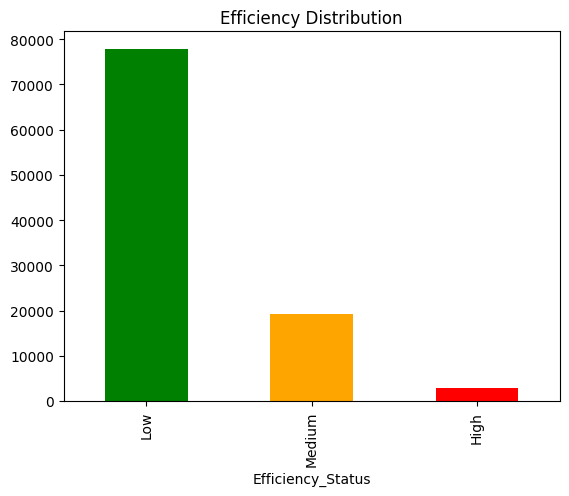

In [13]:
df['Efficiency_Status'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title("Efficiency Distribution")
plt.show()

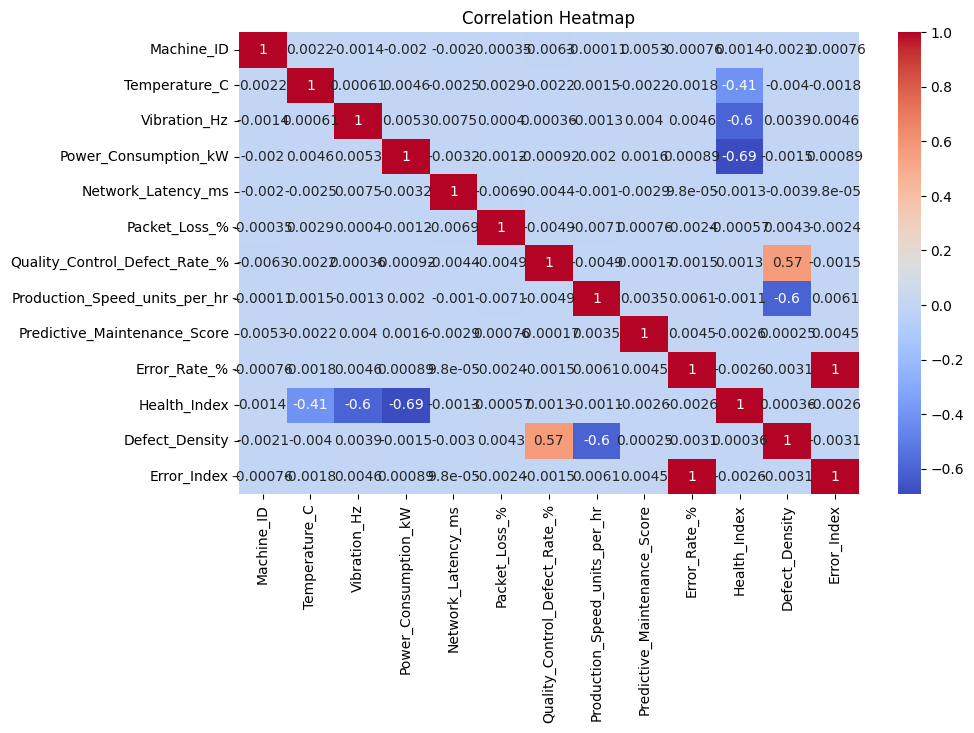

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

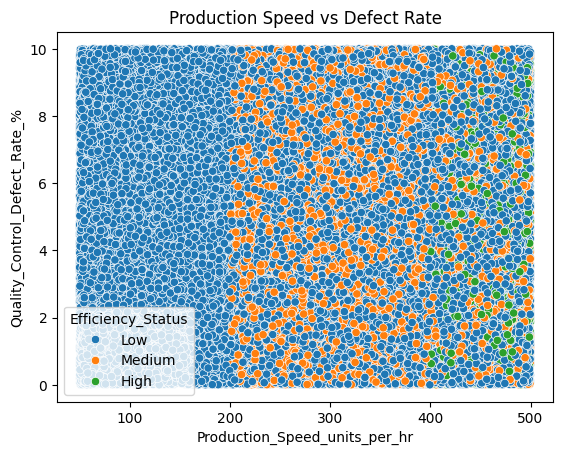

In [15]:
sns.scatterplot(
    data=df,
    x='Production_Speed_units_per_hr',
    y='Quality_Control_Defect_Rate_%',
    hue='Efficiency_Status'
)
plt.title("Production Speed vs Defect Rate")
plt.show()

In [16]:
df.groupby('Operation_Mode')[[
    'Production_Speed_units_per_hr',
    'Quality_Control_Defect_Rate_%',
    'Error_Rate_%'
]].mean()

,Production_Speed_units_per_hr,Quality_Control_Defect_Rate_%,Error_Rate_%
Operation_Mode,,,
Active,276.199269,5.009469,7.494194
Idle,274.125573,5.010452,7.522686
Maintenance,277.543956,5.000770,7.536581


In [17]:
output_path = "processed_factory_data.csv"
df.to_csv(output_path, index=False)

print("Saved in Colab runtime:", output_path)

Saved in Colab runtime: processed_factory_data.csv


In [18]:
from google.colab import files
files.download("processed_factory_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Top 5 worst machines by health
worst_health = df.groupby('Machine_ID')['Health_Index'].mean().nsmallest(5)

# Top 5 machines by defect rate
worst_defects = df.groupby('Machine_ID')['Quality_Control_Defect_Rate_%'].mean().nlargest(5)

# Top 5 machines by error rate
worst_errors = df.groupby('Machine_ID')['Error_Rate_%'].mean().nlargest(5)

print("Worst Health Machines:\n", worst_health)
print("\nWorst Defect Machines:\n", worst_defects)
print("\nWorst Error Machines:\n", worst_errors)

Worst Health Machines:
 Machine_ID
3     0.409240
33    0.411473
44    0.412289
26    0.412552
16    0.412601
Name: Health_Index, dtype: float64

Worst Defect Machines:
 Machine_ID
15    5.165246
9     5.148283
14    5.111299
22    5.095435
47    5.092963
Name: Quality_Control_Defect_Rate_%, dtype: float64

Worst Error Machines:
 Machine_ID
25    7.710648
22    7.659161
29    7.647564
47    7.640245
31    7.624396
Name: Error_Rate_%, dtype: float64


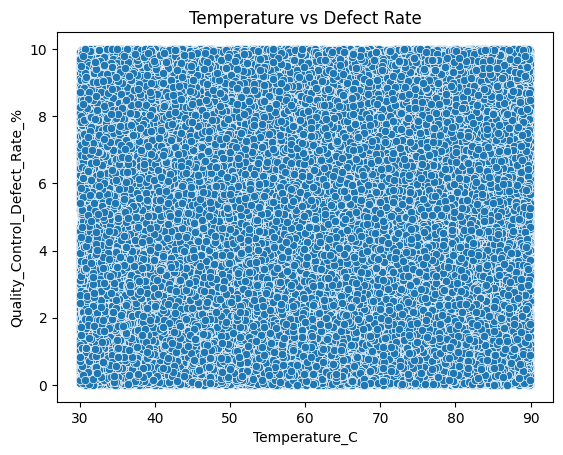

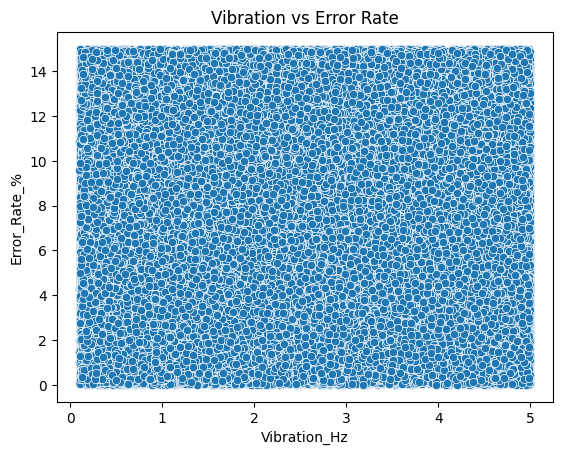

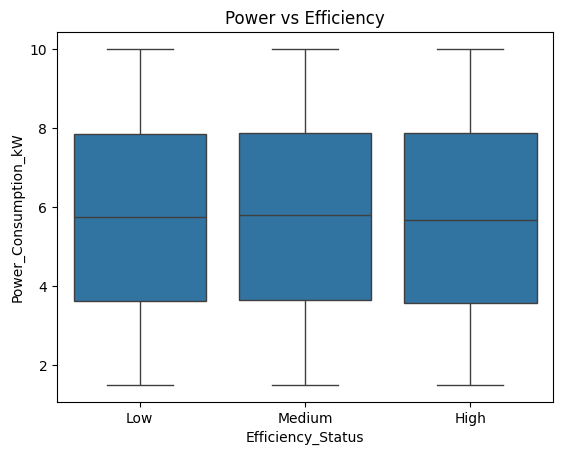

In [20]:
# Temperature vs Defect Rate
sns.scatterplot(data=df, x='Temperature_C', y='Quality_Control_Defect_Rate_%')
plt.title("Temperature vs Defect Rate")
plt.show()

# Vibration vs Error Rate
sns.scatterplot(data=df, x='Vibration_Hz', y='Error_Rate_%')
plt.title("Vibration vs Error Rate")
plt.show()

# Power vs Efficiency
sns.boxplot(data=df, x='Efficiency_Status', y='Power_Consumption_kW')
plt.title("Power vs Efficiency")
plt.show()

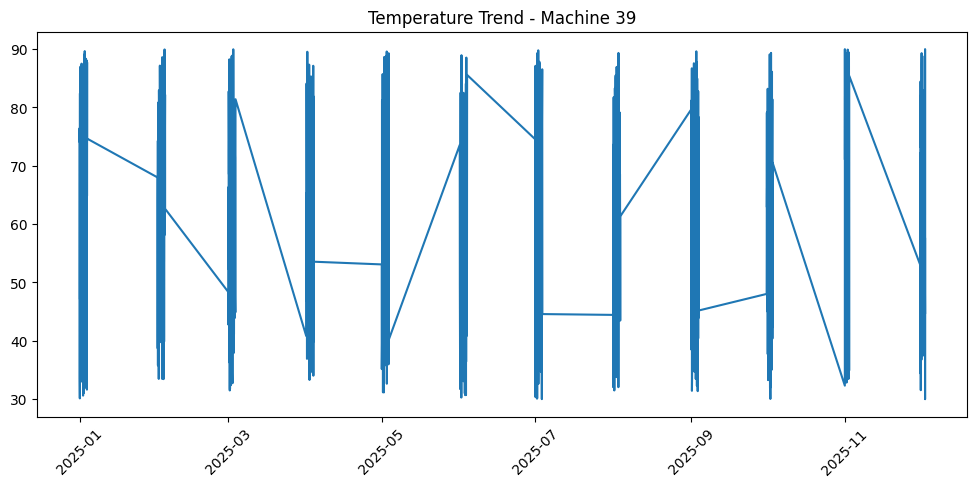

In [21]:
# Pick one machine
machine_id = df['Machine_ID'].iloc[0]
machine_df = df[df['Machine_ID'] == machine_id]

plt.figure(figsize=(12,5))
plt.plot(machine_df['Datetime'], machine_df['Temperature_C'])
plt.title(f"Temperature Trend - Machine {machine_id}")
plt.xticks(rotation=45)
plt.show()

In [22]:
mode_analysis = df.groupby('Operation_Mode')[[
    'Production_Speed_units_per_hr',
    'Quality_Control_Defect_Rate_%',
    'Error_Rate_%',
    'Power_Consumption_kW'
]].mean()

print(mode_analysis)

                Production_Speed_units_per_hr  Quality_Control_Defect_Rate_%  \
Operation_Mode                                                                 
Active                             276.199269                       5.009469   
Idle                               274.125573                       5.010452   
Maintenance                        277.543956                       5.000770   

                Error_Rate_%  Power_Consumption_kW  
Operation_Mode                                      
Active              7.494194              5.751227  
Idle                7.522686              5.734926  
Maintenance         7.536581              5.730708  


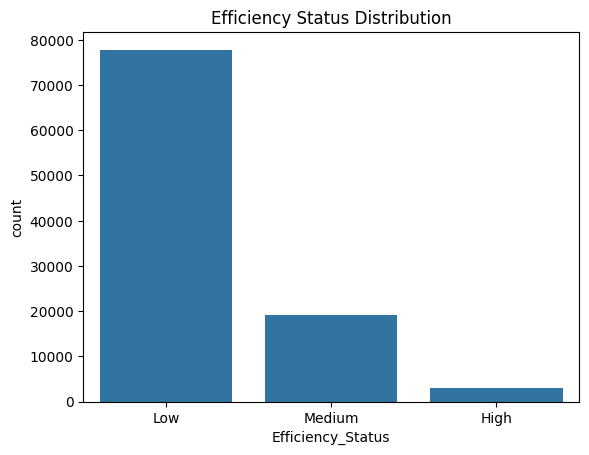

Efficiency_Status  High   Low  Medium
Machine_ID                           
1                    55  1473     388
2                    58  1596     387
3                    56  1574     371
4                    51  1568     385
5                    75  1589     379
6                    58  1493     383
7                    62  1523     380
8                    54  1582     331
9                    54  1582     355
10                   63  1580     379
11                   61  1511     379
12                   51  1516     388
13                   68  1578     394
14                   45  1533     363
15                   71  1543     413
16                   64  1531     415
17                   59  1617     385
18                   61  1601     369
19                   62  1531     411
20                   55  1499     416
21                   57  1602     393
22                   73  1577     381
23                   69  1594     429
24                   73  1512     399
25          

In [23]:
sns.countplot(data=df, x='Efficiency_Status')
plt.title("Efficiency Status Distribution")
plt.show()

# Efficiency per machine
eff_machine = df.groupby('Machine_ID')['Efficiency_Status'].value_counts().unstack()
print(eff_machine)